In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## 과제1. OR 게이트 학습 및 시각화

In [15]:
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [1]])


In [19]:
model1 = Sequential()
model1.add(Dense(4, input_dim=2, activation='relu')) #은닉층 1개
model1.add(Dense(1, activation='sigmoid'))

In [22]:
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model1.fit(X, y, epochs=1000, verbose=0)


In [23]:
pred = model1.predict(X)
print("OR 예측 결과:\n", np.round(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
OR 예측 결과:
 [[0.]
 [1.]
 [1.]
 [1.]]


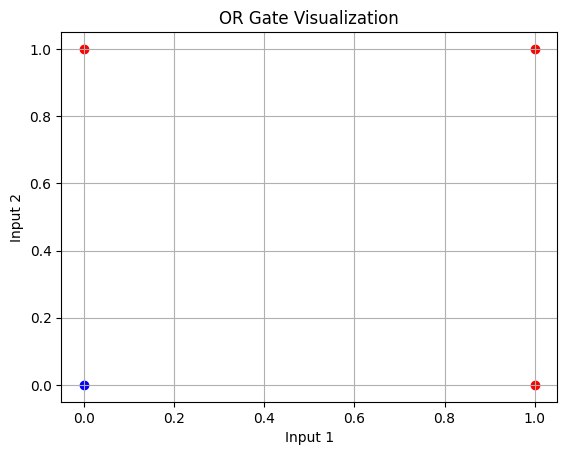

In [9]:
# 시각화
for i, point in enumerate(X):
    plt.scatter(point[0], point[1], c='red' if y[i]==1 else 'blue')
plt.title("OR Gate Visualization")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.grid()
plt.show()

### OR 게이트는 선형 분리가 가능하므로 은닉층 한 개로 충분함.

## 과제2. XOR 게이트 학습 및 시각화

In [24]:
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])


In [25]:
model2 = Sequential()
model2.add(Dense(4, input_dim=2, activation='relu'))  # 은닉층 1개
model2.add(Dense(1, activation='sigmoid'))

In [26]:
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.fit(X, y, epochs=1000, verbose=0)

In [27]:
pred = model2.predict(X)
print("XOR 예측 결과:\n", np.round(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
XOR 예측 결과:
 [[0.]
 [0.]
 [1.]
 [0.]]


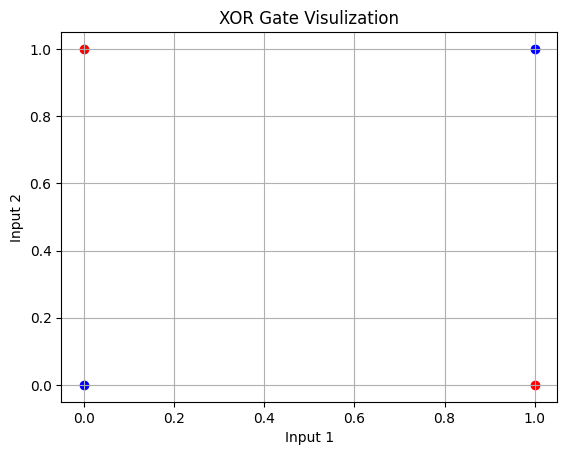

In [28]:
#시각화
for i, point in enumerate(X):
    plt.scatter(point[0], point[1], c='red' if y[i]==1 else 'blue')
plt.title("XOR Gate Visulization")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.grid()
plt.show()

### 시각화에서 알 수 있듯이, 두 클래스가 교차하는 패턴을 보여 은닉층 1개로는 정확히 분리할 수 없어 학습 성능이 떨어짐.

##과제3. XOR 게이트 학습 및 시각화 (DNN)

In [29]:
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

In [30]:
model3 = Sequential()
model3.add(Dense(4, input_dim=2, activation='relu'))  # 첫 번째 은닉층
model3.add(Dense(4, activation='relu'))               # 두 번째 은닉층 2, 기존 1개에서 추가.
model3.add(Dense(1, activation='sigmoid'))

In [31]:
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model3.fit(X, y, epochs=1000, verbose=0)

In [32]:
pred = model3.predict(X)
print("XOR 예측 결과 (DNN):\n", np.round(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
XOR 예측 결과 (DNN):
 [[0.]
 [1.]
 [1.]
 [0.]]


458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


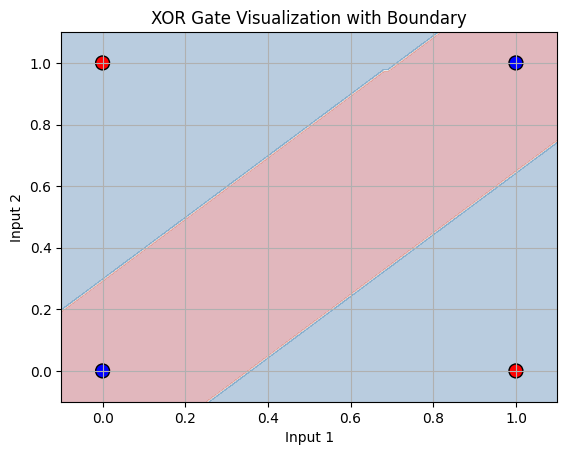

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y, title=""):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    grid = np.c_[xx.ravel(), yy.ravel()]
    pred = model.predict(grid)
    pred = (pred > 0.5).astype(int).reshape(xx.shape)

    plt.contourf(xx, yy, pred, alpha=0.3, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y[:, 0], cmap='bwr', edgecolors='k', s=100)
    plt.title(title)
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.grid()
    plt.show()

# 시각화
plot_decision_boundary(model3, X, y, title="XOR Gate Visualization with Boundary")
